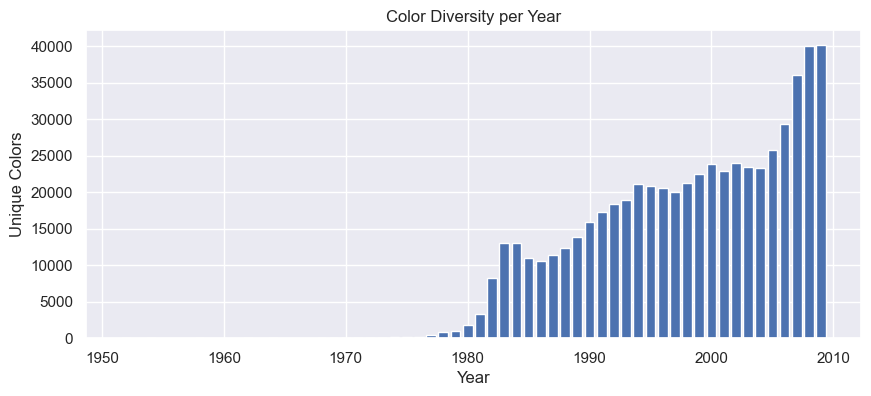

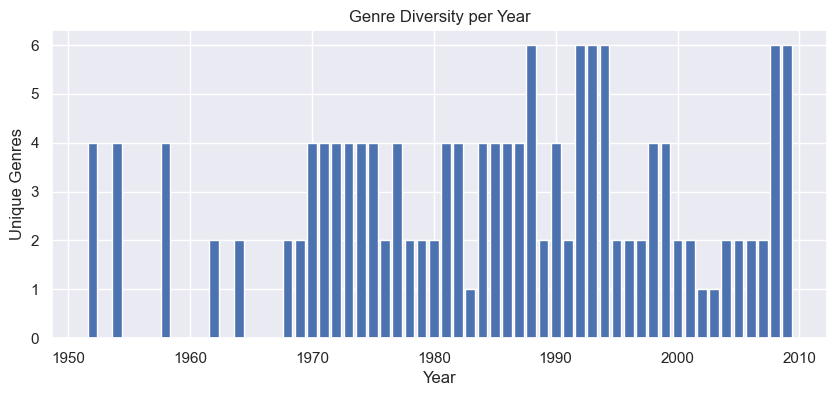

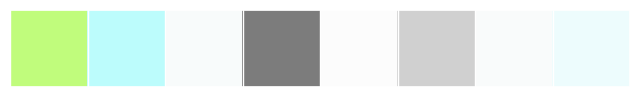

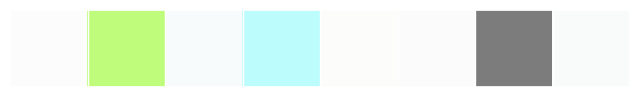

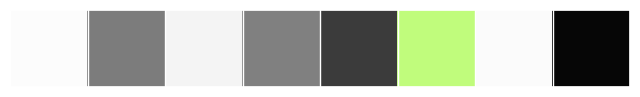

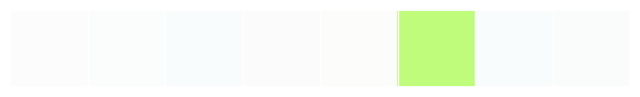

In [ ]:
import ast
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Load palettes
RAW_CSV = r"C:\Users\nina\Documents\UNI\SEM\thesis\coding\game_color_analysis\data\game_info.csv"

PROCESSED_CSV = "processed_color_data.csv"

df = pd.read_csv(RAW_CSV)
# Convert palette strings to Python lists
df["Palette"] = df["Palette"].apply(
    lambda x: ast.literal_eval(x) if pd.notnull(x) else []
)

# Aggregate colors by Year and Decade
year_colors = {}
decade_colors = {}

for _, row in df.iterrows(): #very slow!!! https://stackoverflow.com/questions/16476924/how-can-i-iterate-over-rows-in-a-pandas-dataframe/77270285#77270285
    year = row["Year"]
    decade = row["Decade"]
    colors = row["Palette"]
    genres = row["Genres"]
    themes = row["Themes"]

    year_colors.setdefault(year, []).extend(colors)
    decade_colors.setdefault(decade, []).extend(colors)

# Compute basic statistics
# Color diversity per year
color_diversity = {year: len(set(colors)) for year, colors in year_colors.items()}
genre_diversity = {year: len(set(genres.split(","))) for year, genres in zip(year_colors.keys(), df["Genres"].tolist())}
theme_diversity = {year: len(set(themes.split(","))) for year, themes in zip(year_colors.keys(), df["Themes"].tolist())}

# Dominant colors per year (top 5)
dominant_colors_year = {
    year: [c for c, _ in Counter(colors).most_common(5)]
    for year, colors in year_colors.items()
}

# Dominant colors per decade (top 8)
dominant_colors_decade = {
    decade: [c for c, _ in Counter(colors).most_common(8)]
    for decade, colors in decade_colors.items()
}


# Plots
# plt.figure(figsize=(10, 4))
# plt.bar(color_diversity.keys(), color_diversity.values())
# plt.xlabel("Year")
# plt.ylabel("Unique Colors")
# plt.title("Color Diversity per Year")
# plt.show()

# plt.figure(figsize=(10, 4))
# plt.bar(genre_diversity.keys(), genre_diversity.values())
# plt.xlabel("Year")
# plt.ylabel("Unique Genres")
# plt.title("Genre Diversity per Year")
# plt.show()

sns.set(rc={"figure.figsize": (6, 6)})
current_palette = dominant_colors_decade.get(1970, [])
sns.palplot(current_palette)
sns.set(rc={"figure.figsize": (6, 6)})
current_palette = dominant_colors_decade.get(1980, [])
sns.palplot(current_palette)
sns.set(rc={"figure.figsize": (6, 6)})
current_palette = dominant_colors_decade.get(1990, [])
sns.palplot(current_palette)
sns.set(rc={"figure.figsize": (6, 6)})
current_palette = dominant_colors_decade.get(2000, [])
sns.palplot(current_palette)

sns.set(rc={"figure.figsize": (6, 6)})
current_palette = dominant_colors_year.get(1978, [])
sns.palplot(current_palette)
sns.set(rc={"figure.figsize": (6, 6)})
current_palette = dominant_colors_year.get(1995, [])
sns.palplot(current_palette)
sns.set(rc={"figure.figsize": (6, 6)})
current_palette = dominant_colors_year.get(2003, [])
sns.palplot(current_palette)
# sns.set(rc={"figure.figsize": (6, 6)})
# current_palette = dominant_colors_decade.get(2010, [])
# sns.palplot(current_palette)
# sns.set(rc={"figure.figsize": (6, 6)})
# current_palette = dominant_colors_decade.get(2020, [])
# sns.palplot(current_palette)

# Save preprocessed data for Streamlit
# df.to_csv(PROCESSED_CSV, index=False)
# print(f"[INFO] Preprocessed CSV saved to {PROCESSED_CSV}")
